# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [81]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

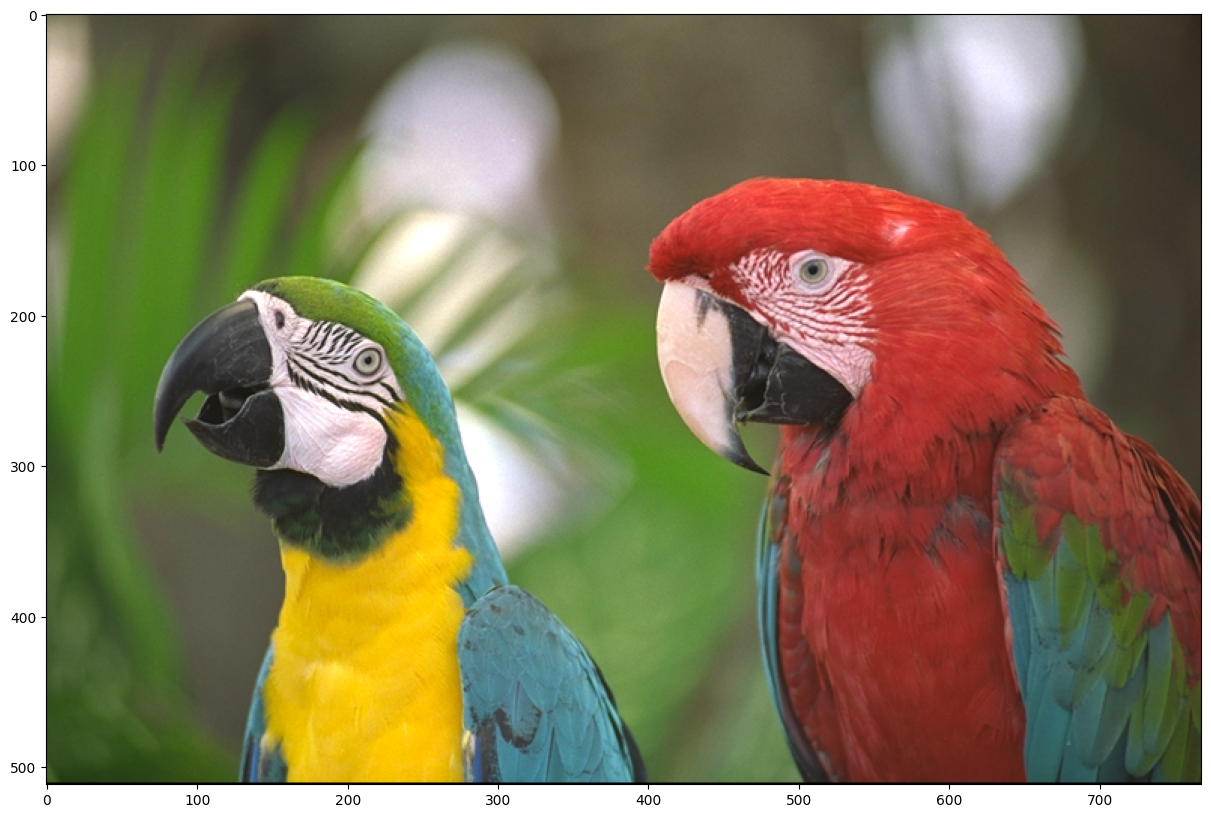

In [82]:
# Load image
img = cv2.imread('kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [104]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

In [84]:
def quntization(img, colors):
    img = img.astype(float)

    # Prepare for quantization
    rows, cols, _ = img.shape
    quantized = np.zeros_like(img)
    total_error = 0
    # Apply quantization
    for r in range(rows):
        for c in range(cols):
            # Extract the original pixel value
            pixel = img[r, c, :]
            
            # Find the closest colour from the pallette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            distances = np.linalg.norm(colors - pixel, axis=1)
            nearest_index = np.argmin(distances)
            new_pixel = colors[nearest_index]
            
            # Apply quantization
            quantized[r, c, :] = new_pixel

            total_error += np.linalg.norm(pixel - new_pixel)

    quantized = quantized.astype(np.uint8)
    avg_quant_error = total_error / (rows * cols)
    return quantized, avg_quant_error

Using the colour pallette, let's quantize the original image.

In [85]:
quantized, avg_quant_error = quntization(np.copy(img), colors)
print(f"Average quantization error (no dithering): {avg_quant_error:.2f}")

Average quantization error (no dithering): 67.73


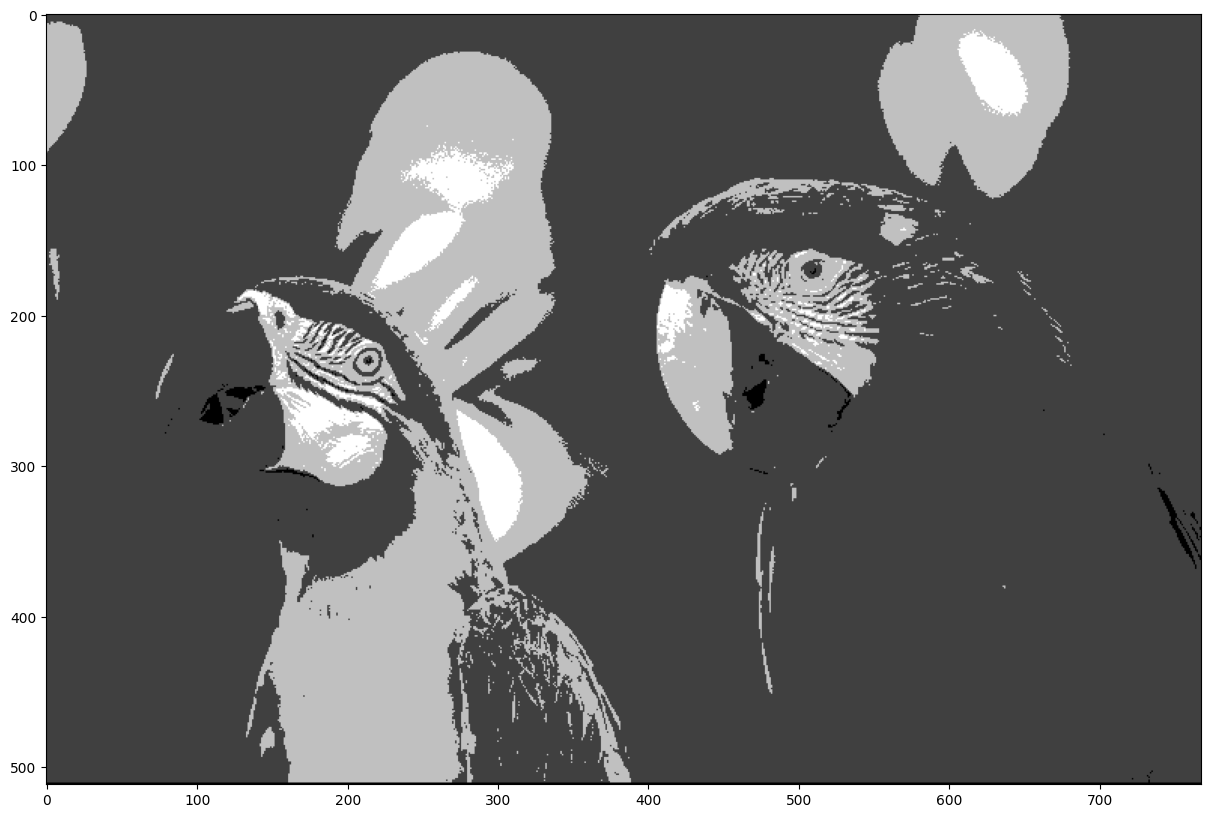

In [86]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized)

#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [115]:
def dithering(img, colors):
    rows, cols, _ = img.shape
    img_tmp = img.astype(float)
    dithered = np.zeros_like(img_tmp)
    total_dith_error = 0

    for r in range(1, rows-1):
        for c in range(1, cols-1):
            # Extract the original pixel value
            pixel = img_tmp[r, c, :]
            # Find the closest colour from the pallette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            distances = np.linalg.norm(colors - pixel, axis=1)
            nearest_index = np.argmin(distances)
            new_pixel = colors[nearest_index]
            
            # Compute quantization error
            quant_error = pixel - new_pixel
            
            # Diffuse the quantization error accroding to the FS diffusion matrix
            # Note: You may need more than one line of code here
            img_tmp[r, c+1]   += quant_error * 7 / 16
            img_tmp[r+1, c-1] += quant_error * 3 / 16
            img_tmp[r+1, c]   += quant_error * 5 / 16
            img_tmp[r+1, c+1] += quant_error * 1 / 16
            
            # Apply dithering
            dithered[r, c, :] = new_pixel

            total_dith_error += np.linalg.norm(quant_error)

    dithered = np.clip(dithered, 0, 255).astype(np.uint8)
    avg_dith_error = total_dith_error / (rows * cols)
    return dithered, avg_dith_error

Average quantization error with dithering: 14523.73


(<Axes: title={'center': 'Dithering'}>,
 <matplotlib.image.AxesImage at 0x17fed0e60>)

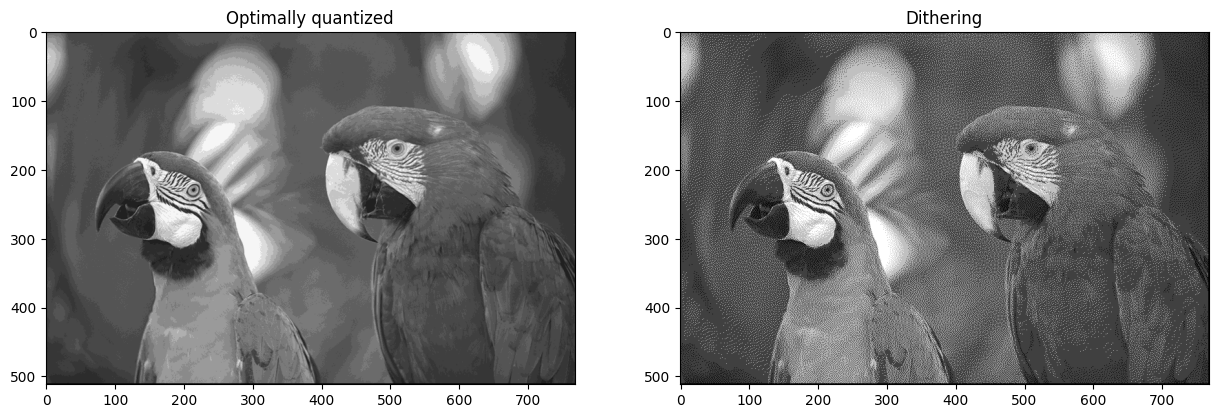

In [137]:
dithered, avg_dith_error = dithering(np.copy(img), colors)
print(f"Average quantization error with dithering: {avg_dith_error:.2f}")
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121, title="Optimally quantized"), plt.imshow(quantized)   # optimally quantized
plt.subplot(122, title="Dithering"), plt.imshow(dithered)   # dithering

### Questions
1. Which image has higher quantization error? Optimally quantized or dithered?
2. Which image looks better to you?
3. Can you repeat the same process using only two colours: black and white? Show me :-)
###
1. Higher quantization error has dithered image 14523.73 against 67.73 for quantization.
2. Definitly dithered image looks better.


Average quantization error (no dithering): 152.54
Average quantization error with dithering: 14528.49


(<Axes: title={'center': 'Dithering (black and white)'}>,
 <matplotlib.image.AxesImage at 0x17b062c30>)

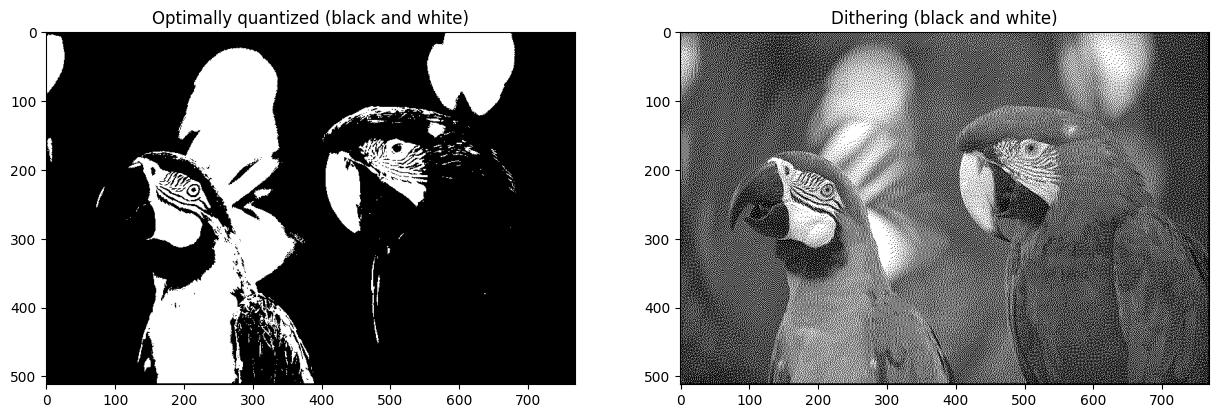

In [117]:
# 3. Can you repeat the same process using only two colours: black and white? Show me :-)
# Black, white
two_colors = np.array([[0, 0, 0],
                       [255, 255, 255]])

quantized, avg_quant_error = quntization(np.copy(img), two_colors)
print(f"Average quantization error (no dithering): {avg_quant_error:.2f}")

dithered, avg_dith_error = dithering(np.copy(img), two_colors)
print(f"Average quantization error with dithering: {avg_dith_error:.2f}")
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121, title="Optimally quantized (black and white)"), plt.imshow(quantized)   # optimally quantized
plt.subplot(122, title="Dithering (black and white)"), plt.imshow(dithered)   # dithering

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [150]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 1)))
colors_kmeans_16 = kmeans.cluster_centers_
print(colors_kmeans_16)



[[ 87.73692632]
 [199.41476105]
 [ 51.33251137]
 [143.45087244]
 [247.19350819]
 [114.00193777]
 [ 29.89763698]
 [ 73.83167209]
 [179.96024328]
 [222.34787836]
 [  3.77868899]
 [159.45712683]
 [100.58022138]
 [ 62.04569478]
 [128.22621449]
 [ 41.60743689]]


Average quantization error (no dithering): 46.96
Average quantization error with dithering: 14522.57


(<Axes: title={'center': 'Dithering (16 colors)'}>,
 <matplotlib.image.AxesImage at 0x168a195e0>)

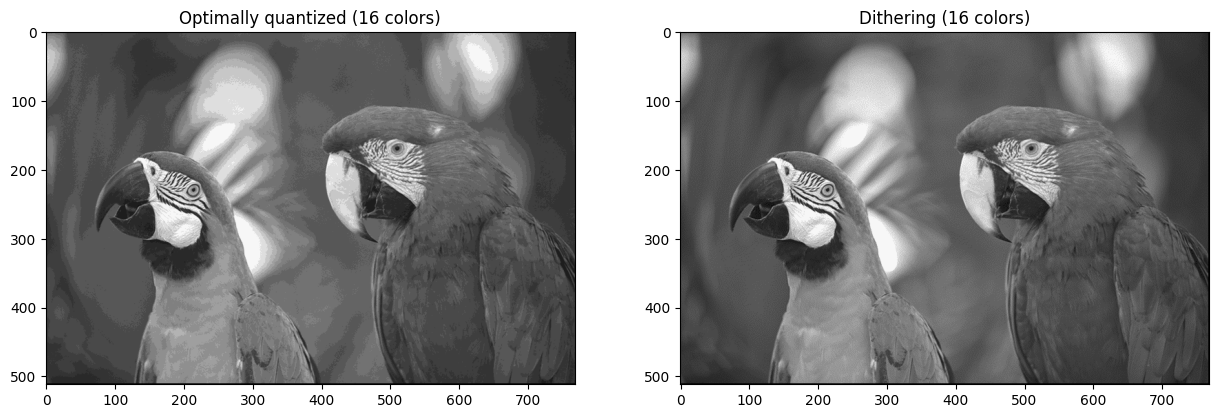

In [151]:
quantized, avg_quant_error = quntization(np.copy(img), colors_kmeans_16)
print(f"Average quantization error (no dithering): {avg_quant_error:.2f}")

dithered, avg_dith_error = dithering(img, colors_kmeans_16)
print(f"Average quantization error with dithering: {avg_dith_error:.2f}")
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121, title="Optimally quantized (16 colors)"), plt.imshow(quantized)   # optimally quantized
plt.subplot(122, title="Dithering (16 colors)"), plt.imshow(dithered)   # dithering

Average quantization error (no dithering): 46.15
Average quantization error with dithering: 14522.52


(<Axes: title={'center': 'Dithering (32 colors)'}>,
 <matplotlib.image.AxesImage at 0x169bbb320>)

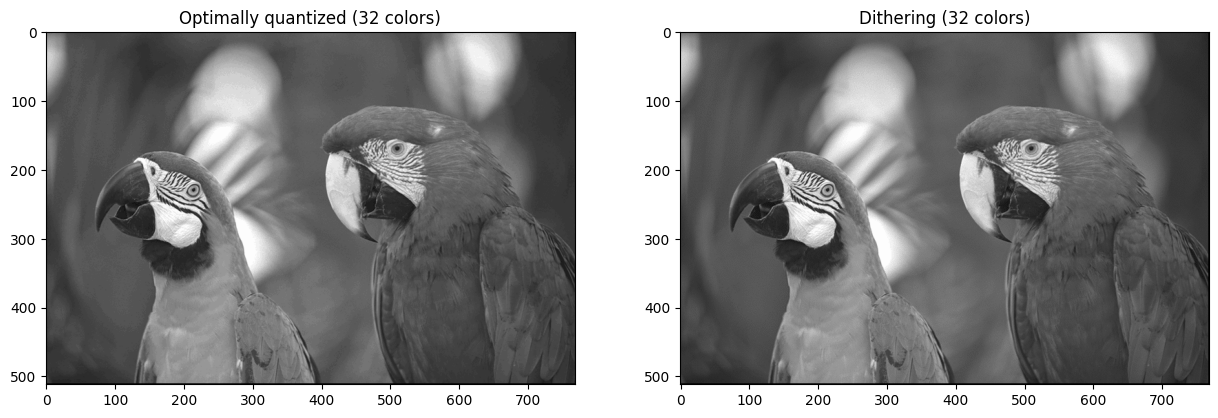

In [154]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=32).fit(np.reshape(img, (-1, 1)))
colors_kmeans_32 = kmeans.cluster_centers_

quantized, avg_quant_error = quntization(np.copy(img), colors_kmeans_32)
print(f"Average quantization error (no dithering): {avg_quant_error:.2f}")

dithered, avg_dith_error = dithering(img, colors_kmeans_32)
print(f"Average quantization error with dithering: {avg_dith_error:.2f}")
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121, title="Optimally quantized (32 colors)"), plt.imshow(quantized)   # optimally quantized
plt.subplot(122, title="Dithering (32 colors)"), plt.imshow(dithered)   # dithering

Average quantization error (no dithering): 45.84
Average quantization error with dithering: 14522.51


(<Axes: title={'center': 'Dithering (256 colors)'}>,
 <matplotlib.image.AxesImage at 0x169ac0530>)

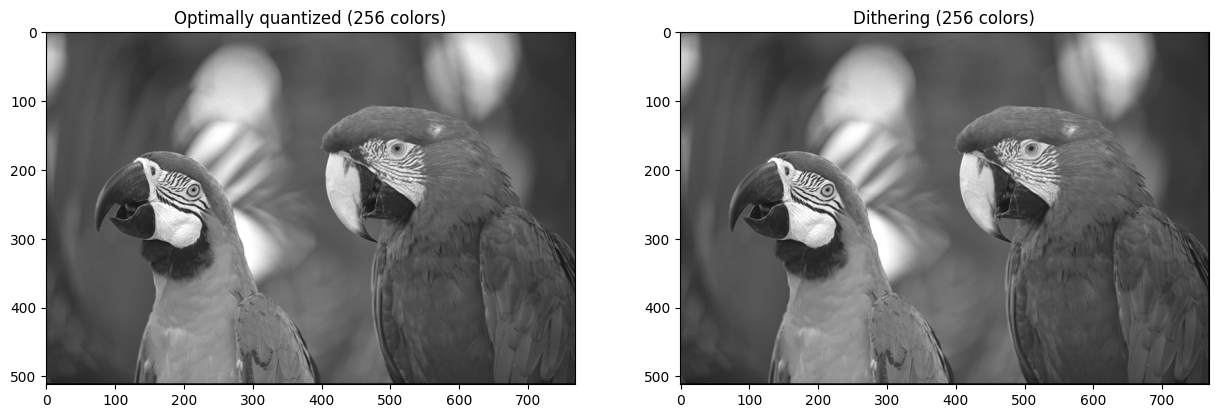

In [155]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=256).fit(np.reshape(img, (-1, 1)))
colors_kmeans_256 = kmeans.cluster_centers_

quantized, avg_quant_error = quntization(np.copy(img), colors_kmeans_256)
print(f"Average quantization error (no dithering): {avg_quant_error:.2f}")

dithered, avg_dith_error = dithering(img, colors_kmeans_256)
print(f"Average quantization error with dithering: {avg_dith_error:.2f}")
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121, title="Optimally quantized (256 colors)"), plt.imshow(quantized)   # optimally quantized
plt.subplot(122, title="Dithering (256 colors)"), plt.imshow(dithered)   # dithering

Apply FS dithering the same way you did before.
* How does the result look like to you?
* What happens if we use 32 colours?
* And what happens if we use 256 colours?
###
1. With 16 colors result looks smoothly and better than with 4 colors. While higher quantization error has dithered image 14522.58.
2. If we use 32 colors diference is little visible, but again dithered image looks better.
3. When we use 256 colors difference isn't visible for me. Images look the same.